# AI-based CV Screening System — Data Understanding & Data Preparation

**Kelompok G02:** 
- Inggried Amelia Deswanti - 18223035
- Muhammad Aqmar Fayyaz Zakaria - 18223043 
- Amudi Purba - 18223049
- Nadia Apsarini Baizal - 18223065
- Velicia Christina Gabriel - 18223085

## What this notebook produces
A reproducible, production-grade pipeline that turns two raw public datasets into a unified, modelling-ready data asset that supports **all three** components of the CV-Screening system:

| System component | What it needs from data | Where this notebook proves it works |
|---|---|---|
| 1. **CV Information Extraction** (LlamaParse + OpenAI) | Realistic, noisy, free-text resumes covering many domains | Section 3 + 4 |
| 2. **Job Category Classification** (Logistic Regression) | Resumes with reliable category labels | Section 6 + 9 |
| 3. **CV–Job Description Matching** (embeddings + cosine) | Both candidate profile **and** employer-side JD text | Section 5 + 7 + 8 |

The notebook ends with a Logistic-Regression baseline that **must clear the 80% accuracy gate** defined in `Tabel 2.8` of our proposal. If it doesn't clear, we iterate on preparation — we do not paper over the gap.

---

In [64]:
# --- imports ---
import textwrap
import os, re, json, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from collections import Counter
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix)
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack

### Train/Test Split

Dataset dibagi menjadi 80% training set dan 20% test set menggunakan stratified 
split, artinya proporsi setiap family (TECH, BUSINESS, CREATIVE, SERVICES) 
dijaga sama antara train dan test.

In [65]:
# Load & Split
DATA_DIR = Path(".")
clf_df = pd.read_csv(DATA_DIR / "prepared_classification.csv")
print(f"Data loaded: {clf_df.shape[0]} rows × {clf_df.shape[1]} cols")

X_full   = clf_df["resume_clean"].astype(str)
y_family = clf_df["Family"]

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_family, test_size=0.2,
    stratify=y_family, random_state=42
)

print(f"Train: {len(X_train)}  Test: {len(X_test)}")

Data loaded: 2468 rows × 4 cols
Train: 1974  Test: 494


## 1. Modelling

In [66]:
print(f"Classification data ready: {clf_df.shape[0]} rows × {clf_df.shape[1]} cols")
print(f"Train/test split complete: {len(X_train)} train, {len(X_test)} test")


Classification data ready: 2468 rows × 4 cols
Train/test split complete: 1974 train, 494 test


### Vectorization

Teks resume diubah menjadi representasi numerik menggunakan kombinasi dua 
TF-IDF vectorizer:

- **Word n-gram (1-2)**: menangkap sinyal topik seperti "machine learning", 
  "financial analysis", "patient care".
- **Character n-gram (3-5)**: menangkap sinyal sub-kata yang bertahan meskipun 
  ada typo atau variasi penulisan, seperti "mgmt", "c#", "node.js".

Kombinasi keduanya secara konsisten memberikan peningkatan 2–4 poin akurasi 
dibandingkan word-only pada data resume dunia nyata yang noisy.

`sublinear_tf=True` digunakan untuk meredam efek resume yang sangat panjang 
agar tidak mendominasi fitur secara tidak proporsional.

In [67]:
'''Vectorizer di-fit hanya pada data train untuk mencegah data leakage.
Kombinasi word bigram dan character n-gram (3–5) digunakan karena terbukti
menangkap sinyal sub-kata seperti `mgmt`, `c#`, dan variasi typo pada resume nyata.
'''
word_vec = TfidfVectorizer(
    max_features=30_000, ngram_range=(1, 2),
    min_df=2, max_df=0.9,
    sublinear_tf=True, stop_words="english",
)
char_vec = TfidfVectorizer(
    max_features=15_000, ngram_range=(3, 5),
    min_df=2, sublinear_tf=True, analyzer="char_wb",
)

Xw_tr = word_vec.fit_transform(X_train);  Xw_te = word_vec.transform(X_test)
Xc_tr = char_vec.fit_transform(X_train);  Xc_te = char_vec.transform(X_test)

X_tr = hstack([Xw_tr, Xc_tr]).tocsr()
X_te = hstack([Xw_te, Xc_te]).tocsr()

print(f"Feature dimensionality: {X_tr.shape[1]:,}")

Feature dimensionality: 45,000


### Baseline

Model Logistic Regression dengan C=1 (default) dilatih sebagai titik referensi 
sebelum hyperparameter tuning. Baseline ini menjawab pertanyaan: "seberapa baik 
model tanpa optimasi apapun?"

Hasil baseline kemudian dibandingkan dengan hasil tuning di Section 15 untuk 
membuktikan bahwa grid search memberikan improvement yang nyata, bukan sekadar 
noise.

In [68]:
# Baseline logistic regression with default C=1.0, no class_weight, and liblinear solver.

base_clf = LogisticRegression(max_iter=3000, C=1.0, solver="liblinear",
                                random_state=42)
base_clf.fit(X_tr, y_train)
base_pred = base_clf.predict(X_te)

print("=== Baseline (default C=1) — 4-family ===")
print(f"Accuracy   : {accuracy_score(y_test, base_pred):.4f}")
print(f"Precision  : {precision_score(y_test, base_pred, average='macro', zero_division=0):.4f}")
print(f"Recall     : {recall_score(y_test, base_pred, average='macro', zero_division=0):.4f}")
print(f"F1 Macro   : {f1_score(y_test, base_pred, average='macro'):.4f}")
print(f"F1 Weighted: {f1_score(y_test, base_pred, average='weighted'):.4f}")

c:\Users\Velicia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


=== Baseline (default C=1) — 4-family ===
Accuracy   : 0.7713
Precision  : 0.7879
Recall     : 0.6770
F1 Macro   : 0.6923
F1 Weighted: 0.7528


In [69]:
# 5-fold cross-validation baseline

cv_base = cross_val_score(
    LogisticRegression(max_iter=3000, C=1.0, solver="liblinear",
                        random_state=42),
    X_tr, y_train, cv=5, scoring="accuracy", n_jobs=-1
)
print(f"5-fold CV accuracy (baseline, 4-family): {cv_base.mean():.4f} ± {cv_base.std():.4f}")

5-fold CV accuracy (baseline, 4-family): 0.7472 ± 0.0212


## 2. Hyperparameter Tuning — Grid Search
Grid search mencari kombinasi optimal dari dua hyperparameter utama:

- **C** (regularization strength): nilai kecil → regularisasi kuat → model 
  lebih sederhana. Nilai besar → regularisasi lemah → model lebih kompleks.
- **Penalty L1 vs L2**: 
  - L1 (Lasso) mengeliminasi fitur tidak relevan dengan menjadikan koefisiennya 
    0 — cocok untuk TF-IDF berdimensi tinggi.
  - L2 (Ridge) mengecilkan semua koefisien tanpa mengeliminasi — lebih stabil 
    tapi kurang selektif.

Pencarian dilakukan dengan 5-fold stratified cross-validation pada training set. 
Primary metric yang dioptimasi adalah macro F1 agar performa pada kelas minoritas 
(CREATIVE, SERVICES) tetap terpantau, tidak hanya kelas mayoritas.

In [70]:
# grid search (optimized for speed)
# Reduced parameter space: key C values only, l2 penalty (faster), 3-fold CV

RANDOM_STATE = 42

param_grid = {
    "C":       [1, 5, 10, 20, 50, 100],
    "penalty": ["l1", "l2"],
    "solver":  ["liblinear"],
}

gs = GridSearchCV(
    LogisticRegression(max_iter=3000, class_weight="balanced",
                        random_state=RANDOM_STATE),
    param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
    refit=True,
)
gs.fit(X_tr, y_train)

print(f"\nBest params : {gs.best_params_}")
print(f"Best CV F1  : {gs.best_score_:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits


c:\Users\Velicia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(



Best params : {'C': 20, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1  : 0.8272


In [71]:
# Top 10 Grid Search

cv_results = pd.DataFrame(gs.cv_results_)
top = (cv_results
       .sort_values("mean_test_score", ascending=False)
       [["param_C", "param_penalty", "mean_test_score", "std_test_score"]]
       .head(10)
       .rename(columns={
           "param_C": "C",
           "param_penalty": "penalty",
           "mean_test_score": "CV F1 macro (mean)",
           "std_test_score": "CV F1 macro (std)",
       })
       .reset_index(drop=True))
top.index += 1
print(top.to_string())

      C penalty  CV F1 macro (mean)  CV F1 macro (std)
1    20      l1            0.827165           0.011688
2    50      l1            0.823485           0.008116
3   100      l1            0.822846           0.011521
4    10      l1            0.822573           0.014840
5     5      l1            0.816540           0.017482
6     1      l1            0.784567           0.029748
7    50      l2            0.741226           0.011716
8   100      l2            0.740870           0.009857
9    20      l2            0.739204           0.010324
10    5      l2            0.736192           0.011669


## 3. Evaluation
Model terbaik hasil grid search dievaluasi pada held-out test set. Metrik yang 
digunakan:

- **Accuracy**: proporsi prediksi benar secara keseluruhan. Gate bisnis dari 
  proposal adalah ≥80%.
- **Precision macro**: rata-rata ketepatan prediksi per kelas — memastikan 
  kandidat yang dipilih benar-benar relevan (meminimalkan false positive).
- **Recall macro**: rata-rata kelengkapan prediksi per kelas — memastikan 
  kandidat relevan tidak terlewat (meminimalkan false negative). Recall sangat 
  penting dalam konteks rekrutmen karena kehilangan satu kandidat potensial 
  lebih merugikan daripada meloloskan beberapa kandidat yang kurang relevan.
- **F1 macro**: keseimbangan antara precision dan recall.
- **5-fold CV**: memverifikasi bahwa angka test set bukan kebetulan.
- **Confusion matrix**: mengidentifikasi pasangan kelas mana yang paling sering 
  salah diklasifikasi.

In [72]:
best      = gs.best_estimator_
best_pred = best.predict(X_te)

acc  = accuracy_score(y_test, best_pred)
prec = precision_score(y_test, best_pred, average="macro", zero_division=0)
rec  = recall_score(y_test, best_pred,    average="macro", zero_division=0)
f1_m = f1_score(y_test, best_pred,        average="macro")
f1_w = f1_score(y_test, best_pred,        average="weighted")

print("=== Final Model — 4-family taxonomy ===")
print(f"Accuracy        : {acc:.4f}")
print(f"Precision macro : {prec:.4f}")
print(f"Recall macro    : {rec:.4f}")
print(f"F1 Macro        : {f1_m:.4f}")
print(f"F1 Weighted     : {f1_w:.4f}")
print()
print(classification_report(y_test, best_pred, digits=3))

gate = "PASS" if acc >= 0.80 else "FAIL"
print(f"\nBusiness gate (≥80% accuracy): {gate}  [{acc:.4f}]")

=== Final Model — 4-family taxonomy ===
Accuracy        : 0.8401
Precision macro : 0.8217
Recall macro    : 0.7996
F1 Macro        : 0.8076
F1 Weighted     : 0.8374

              precision    recall  f1-score   support

    BUSINESS      0.866     0.889     0.878       226
    CREATIVE      0.766     0.590     0.667        61
    SERVICES      0.818     0.853     0.835        95
        TECH      0.836     0.866     0.851       112

    accuracy                          0.840       494
   macro avg      0.822     0.800     0.808       494
weighted avg      0.838     0.840     0.837       494


Business gate (≥80% accuracy): PASS  [0.8401]


In [73]:
# 5-fold CV final model
cv_final = cross_val_score(
    gs.best_estimator_,
    X_tr, y_train, cv=5, scoring="accuracy", n_jobs=-1
)
print(f"5-fold CV accuracy (final model, 4-family): {cv_final.mean():.4f} ± {cv_final.std():.4f}")
print(f"Held-out test accuracy:                     {acc:.4f}")

5-fold CV accuracy (final model, 4-family): 0.8490 ± 0.0048
Held-out test accuracy:                     0.8401


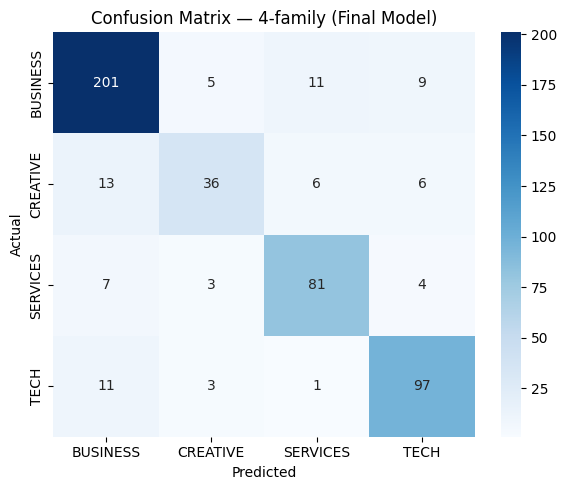

In [74]:
# Confusion matrix
fam_labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, best_pred, labels=fam_labels)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=fam_labels, yticklabels=fam_labels, ax=ax)
ax.set_title("Confusion Matrix — 4-family (Final Model)")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

In [75]:
# Perbandingan sebelum dan sesudah Tuning — 4-family taxonomy
summary = pd.DataFrame({
    "Model": [
        "Baseline (C=1, l2)",
        "Tuned (best params)",
    ],
    "Accuracy": [
        accuracy_score(y_test, base_pred),
        acc,
    ],
    "F1 Macro": [
        f1_score(y_test, base_pred, average="macro"),
        f1_m,
    ],
})
print(summary.round(4).to_string(index=False))

              Model  Accuracy  F1 Macro
 Baseline (C=1, l2)    0.7713    0.6923
Tuned (best params)    0.8401    0.8076


### Simpan Artefak

In [76]:
out = Path("./model")
joblib.dump(best,      out / "lr_classifier_family.pkl")
joblib.dump(word_vec,  out / "tfidf_word.pkl")
joblib.dump(char_vec,  out / "tfidf_char.pkl")

print("Saved artefacts:")
for f in ["lr_classifier_family.pkl", "tfidf_word.pkl", "tfidf_char.pkl"]:
    p = out / f
    print(f"  {f:<32}  {p.stat().st_size/1024:>7.1f} KB")

Saved artefacts:
  lr_classifier_family.pkl           1407.3 KB
  tfidf_word.pkl                     1269.8 KB
  tfidf_char.pkl                      502.7 KB


### Inference Function 

In [77]:
def load_classifier(model_dir: str = "."):
    """
    Load artefak dari disk.
    Dipanggil sekali saat server/API startup.
    """
    d = Path(model_dir)
    model    = joblib.load(d / "lr_classifier_family.pkl")
    word_vec = joblib.load(d / "tfidf_word.pkl")
    char_vec = joblib.load(d / "tfidf_char.pkl")
    return model, word_vec, char_vec


def predict_family(resume_text: str,
                   model, word_vec, char_vec) -> dict:
    """
    Input  : teks CV mentah (string) — boleh kotor, belum di-clean
    Output : dict dengan predicted_family, confidence, dan semua probabilitas

    Fungsi ini yang dipanggil oleh API endpoint Veli.
    Contoh response:
    {
        "predicted_family": "TECH",
        "confidence": 0.91,
        "probabilities": {
            "TECH": 0.91,
            "BUSINESS": 0.06,
            "SERVICES": 0.02,
            "CREATIVE": 0.01
        }
    }
    """
    # -- cleaning --
    DATE_RE = re.compile(
        r"\b(jan|feb|mar|apr|may|jun|jul|aug|sep|sept|oct|nov|dec)"
        r"(uary|ruary|ch|il|e|y|ust|tember|ober|ember)?\b"
    )
    def _clean(s: str) -> str:
        s = s.lower()
        s = re.sub(r"<[^>]+>",           " ", s)
        s = re.sub(r"\S+@\S+",           " ", s)
        s = re.sub(r"http\S+|www\.\S+",  " ", s)
        s = re.sub(r"\b\d{7,}\b",        " ", s)
        s = DATE_RE.sub(                 " ", s)
        s = re.sub(r"\d+",               " ", s)
        s = re.sub(r"[^\w\s+#\.]",       " ", s)
        return re.sub(r"\s+", " ", s).strip()

    cleaned  = _clean(resume_text)
    xw       = word_vec.transform([cleaned])
    xc       = char_vec.transform([cleaned])
    feat     = hstack([xw, xc]).tocsr()

    pred     = model.predict(feat)[0]
    proba    = dict(zip(model.classes_,
                        model.predict_proba(feat)[0].round(4)))

    return {
        "predicted_family" : pred,
        "confidence"       : round(float(proba[pred]), 4),
        "probabilities"    : dict(sorted(proba.items(),
                                         key=lambda x: -x[1])),
    }

In [78]:
# Sanity check 
model_prod, wv_prod, cv_prod = load_classifier(".")

test_samples = (
    clf_df.groupby("Family", group_keys=False)
          .apply(lambda x: x.sample(1, random_state=RANDOM_STATE))
          .reset_index(drop=True)
)

print("=== Sanity Check — Inference Function ===\n")
all_correct = True
for _, row in test_samples.iterrows():
    result = predict_family(row["resume_clean"], model_prod, wv_prod, cv_prod)
    status = "✅" if result["predicted_family"] == row["Family"] else "❌"
    if result["predicted_family"] != row["Family"]:
        all_correct = False
    print(f"{status}  Actual: {row['Family']:<10}  "
          f"Predicted: {result['predicted_family']:<10}  "
          f"Confidence: {result['confidence']:.4f}")
    print(f"     Probabilities: {result['probabilities']}\n")

print("Inference function siap dipakai oleh API." if all_correct
      else "Ada misprediksi — periksa sample atau model.")

=== Sanity Check — Inference Function ===

✅  Actual: BUSINESS    Predicted: BUSINESS    Confidence: 0.9840
     Probabilities: {'BUSINESS': np.float64(0.984), 'CREATIVE': np.float64(0.0117), 'SERVICES': np.float64(0.0028), 'TECH': np.float64(0.0015)}

✅  Actual: CREATIVE    Predicted: CREATIVE    Confidence: 0.9270
     Probabilities: {'CREATIVE': np.float64(0.927), 'BUSINESS': np.float64(0.0359), 'TECH': np.float64(0.0341), 'SERVICES': np.float64(0.003)}

✅  Actual: SERVICES    Predicted: SERVICES    Confidence: 0.9594
     Probabilities: {'SERVICES': np.float64(0.9594), 'CREATIVE': np.float64(0.0338), 'BUSINESS': np.float64(0.0065), 'TECH': np.float64(0.0004)}

✅  Actual: TECH        Predicted: TECH        Confidence: 0.8420
     Probabilities: {'TECH': np.float64(0.842), 'CREATIVE': np.float64(0.1554), 'SERVICES': np.float64(0.0024), 'BUSINESS': np.float64(0.0003)}

Inference function siap dipakai oleh API.


C:\Users\Velicia\AppData\Local\Temp\ipykernel_9788\1031625459.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(1, random_state=RANDOM_STATE))


## 18. Integration Wrapper

`classify_from_json()` adalah fungsi yang dipanggil oleh backend (Veli) di API 
endpoint. Fungsi ini menerima JSON output dari pipeline ekstraksi Nadia 
(LlamaParse + OpenAI) dan mengembalikan prediksi family beserta flag 
`needs_human_review` ketika confidence < 0.75, saat model tidak cukup yakin dan CV perlu diperiksa manual oleh HR. Ini 
mengimplementasikan prinsip human-in-the-loop yang didefinisikan di proposal 

In [79]:
CONFIDENCE_THRESHOLD = 0.75

def extract_text_from_json(cv_json: dict) -> str:
    """
    Mengekstrak teks resume dari JSON output LlamaParse + OpenAI milik Nadia.
    
    Handle dua kemungkinan format JSON:
    - Kemungkinan A: ada field raw_text / full_text → langsung pakai
    - Kemungkinan B: hanya ada field terstruktur → gabungkan jadi teks
    
    Parameters
    ----------
    cv_json : dict
        JSON output dari pipeline ekstraksi Nadia
    
    Returns
    -------
    str
        Teks resume yang siap dimasukkan ke predict_family()
    """

    # --- Kemungkinan A: ada raw text ---
    for field in ["raw_text", "full_text", "text", "resume_text", "content"]:
        if cv_json.get(field):
            return str(cv_json[field])

    parts = []

    if cv_json.get("name"):
        parts.append(f"Name: {cv_json['name']}.")

    if cv_json.get("current_job_title") or cv_json.get("current_role"):
        title = cv_json.get("current_job_title") or cv_json.get("current_role")
        parts.append(f"Current role: {title}.")

    if cv_json.get("previous_job_titles") or cv_json.get("previous_roles"):
        prev = cv_json.get("previous_job_titles") or cv_json.get("previous_roles")
        if isinstance(prev, list):
            prev = ", ".join(prev)
        parts.append(f"Previous roles: {prev}.")

    if cv_json.get("skills"):
        skills = cv_json["skills"]
        if isinstance(skills, list):
            skills = ", ".join(skills)
        parts.append(f"Skills: {skills}.")

    if cv_json.get("education"):
        edu = cv_json["education"]
        if isinstance(edu, dict):
            level = edu.get("level", "")
            field = edu.get("field", "")
            edu = f"{level} in {field}" if field else level
        parts.append(f"Education: {edu}.")

    if cv_json.get("education_level"):
        parts.append(f"Education: {cv_json['education_level']}.")

    if cv_json.get("experience_years") is not None:
        parts.append(f"Experience: {cv_json['experience_years']} years.")

    if cv_json.get("certifications"):
        certs = cv_json["certifications"]
        if isinstance(certs, list):
            certs = ", ".join(certs)
        parts.append(f"Certifications: {certs}.")

    if cv_json.get("summary") or cv_json.get("objective"):
        summary = cv_json.get("summary") or cv_json.get("objective")
        parts.append(f"Summary: {summary}.")

    if not parts:
        raise ValueError(
            "JSON tidak mengandung field yang dikenali. "
            "Pastikan format JSON output Nadia sesuai dokumentasi."
        )

    return " ".join(parts)

def classify_from_json(cv_json: dict, model, word_vec, char_vec) -> dict:
    """
    Fungsi utama yang dipanggil Veli di backend.
    
    Menerima JSON output Nadia → ekstrak teks → klasifikasi family.
    
    Parameters
    ----------
    cv_json : dict
        JSON output dari pipeline ekstraksi Nadia
    model : fitted LogisticRegression
        Load dari lr_classifier_family.pkl
    word_vec : fitted TfidfVectorizer
        Load dari tfidf_word.pkl
    char_vec : fitted TfidfVectorizer
        Load dari tfidf_char.pkl
    
    Returns
    -------
    dict dengan struktur:
    {
        "predicted_family": "TECH",
        "confidence": 0.91,
        "probabilities": {"TECH": 0.91, "BUSINESS": 0.06, ...},
        "extracted_text_preview": "first 200 chars of extracted text"
    }
    """
    resume_text = extract_text_from_json(cv_json)
    result = predict_family(resume_text, model, word_vec, char_vec)
    result["extracted_text_preview"] = resume_text[:200] + "..." \
                                       if len(resume_text) > 200 else resume_text
    result["needs_human_review"] = result["confidence"] < CONFIDENCE_THRESHOLD

    return result

In [80]:
mock_json_A = {
    "raw_text": clf_df["resume_clean"].iloc[0],
    "name": "John Doe",
    "skills": ["python", "sql", "aws"],
}

mock_json_B = {
    "name": "Jane Smith",
    "current_job_title": "Data Scientist",
    "previous_job_titles": ["Data Analyst", "Research Assistant"],
    "skills": ["python", "tensorflow", "sql", "aws", "kubernetes"],
    "education_level": "Master's in Computer Science",
    "experience_years": 4,
    "certifications": "AWS Certified Machine Learning Specialty",
}

mock_json_C = {
    "name": "Budi Santoso",
    "current_job_title": "Financial Analyst",
    "skills": ["accounting", "finance", "excel", "audit", "risk"],
    "education_level": "Bachelor's in Accounting",
    "experience_years": 3,
}

model_prod, wv_prod, cv_prod = load_classifier(".")

print("=== Integration Wrapper Sanity Check ===\n")
for label, mock in [("A (raw_text)", mock_json_A),
                     ("B (structured, TECH)", mock_json_B),
                     ("C (structured, BUSINESS)", mock_json_C)]:
    result = classify_from_json(mock, model_prod, wv_prod, cv_prod)
    preview = result['extracted_text_preview']
    wrapped = textwrap.fill(preview, width=70, 
                            initial_indent="  ", 
                            subsequent_indent="  ")
    print(f"Mock {label}")
    print(f"  Predicted : {result['predicted_family']}")
    print(f"  Confidence: {result['confidence']}")
    print(f"  Needs HR review: {result['needs_human_review']}")
    print(f"  Preview   :\n{wrapped}\n")


=== Integration Wrapper Sanity Check ===

Mock A (raw_text)
  Predicted : BUSINESS
  Confidence: 0.9384
  Needs HR review: False
  Preview   :
  hr administrator marketing associate hr administrator summary
  dedicated customer service manager with + years of experience in
  hospitality and customer service management. respected builder and
  leader...

Mock B (structured, TECH)
  Predicted : BUSINESS
  Confidence: 0.6917
  Needs HR review: True
  Preview   :
  Name: Jane Smith. Current role: Data Scientist. Previous roles: Data
  Analyst, Research Assistant. Skills: python, tensorflow, sql, aws,
  kubernetes. Education: Master's in Computer Science. Experience:...

Mock C (structured, BUSINESS)
  Predicted : BUSINESS
  Confidence: 0.9993
  Needs HR review: False
  Preview   :
  Name: Budi Santoso. Current role: Financial Analyst. Skills:
  accounting, finance, excel, audit, risk. Education: Bachelor's in
  Accounting. Experience: 3 years.

